# RSME hdd

In [6]:
import pandas as pd

df = pd.read_csv("bk_rmse_hdd.csv")

df_long = df.melt(
    id_vars=["region", "year", "model"],
    var_name="horizon",
    value_name="rmse"
)

# convert horizon to numeric when possible
df_long["horizon"] = pd.to_numeric(df_long["horizon"], errors="coerce")

df_long.head(7)

,region,year,model,horizon,rmse
0,11,2015,HBA,30.0,3.327453
1,11,2015,Alaton,30.0,3.125394
2,11,2015,Benth,30.0,3.230219
3,11,2015,XGB,30.0,3.180025
4,11,2015,WaveletFNN,30.0,3.840478
5,11,2015,LSTM,30.0,3.381965
6,11,2015,FeedForwardNN,30.0,3.366983


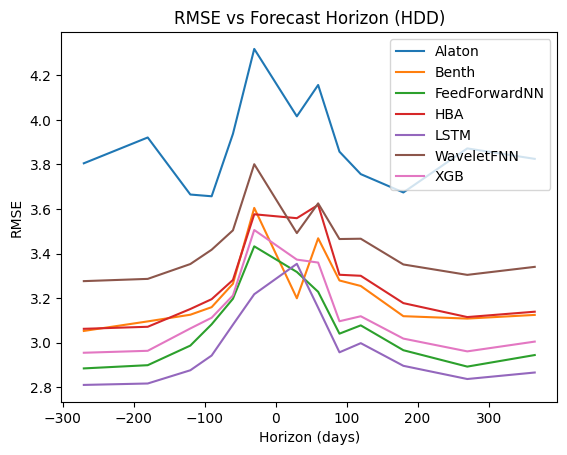

In [7]:
import matplotlib.pyplot as plt

avg = df_long.groupby(["model", "horizon"])["rmse"].mean().reset_index()

for model in avg["model"].unique():
    sub = avg[avg["model"] == model]
    plt.plot(sub["horizon"], sub["rmse"], label=model)

plt.legend()
plt.title("RMSE vs Forecast Horizon (HDD)")
plt.xlabel("Horizon (days)")
plt.ylabel("RMSE")
plt.show()

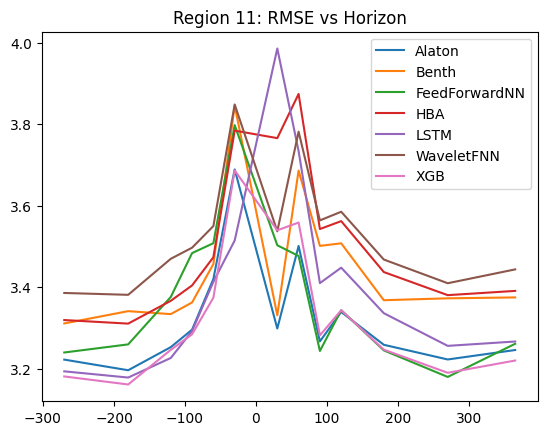

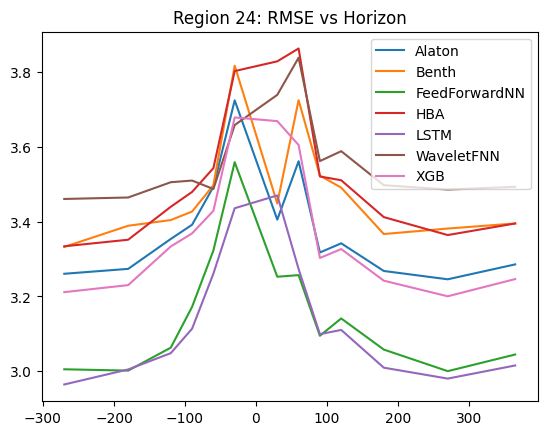

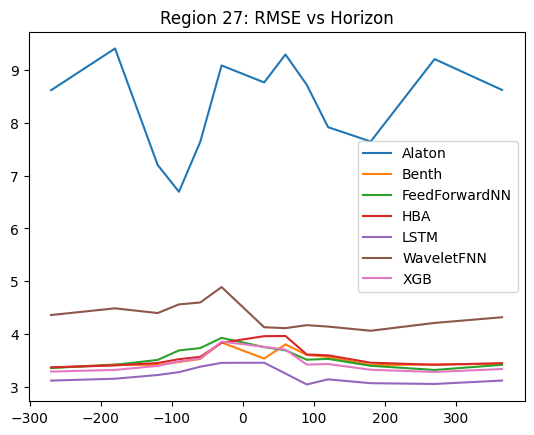

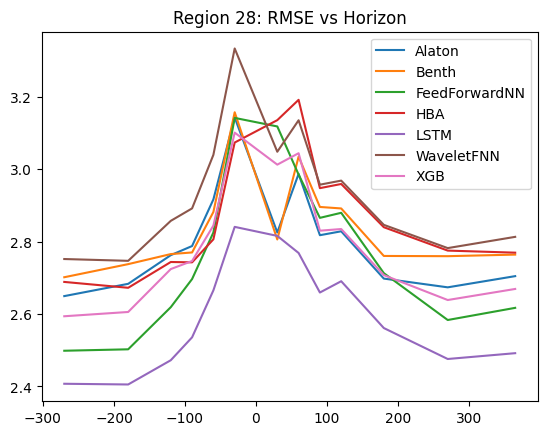

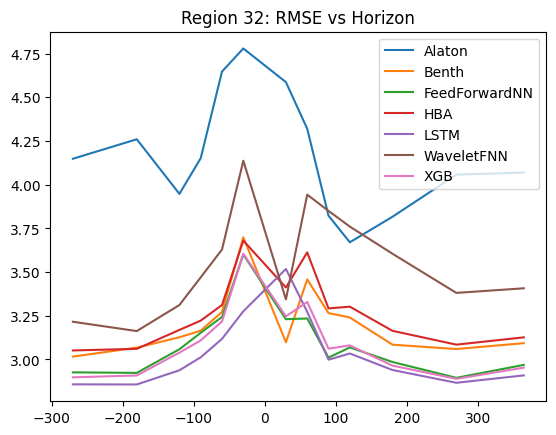

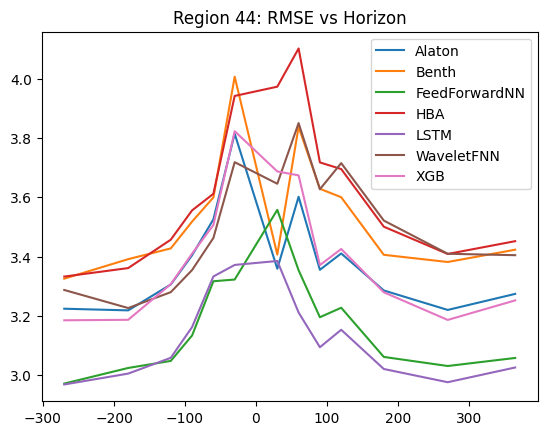

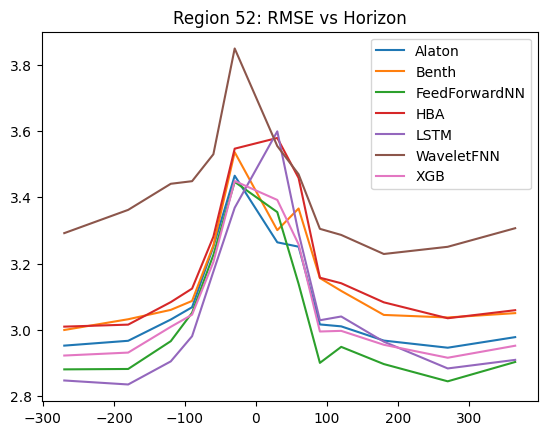

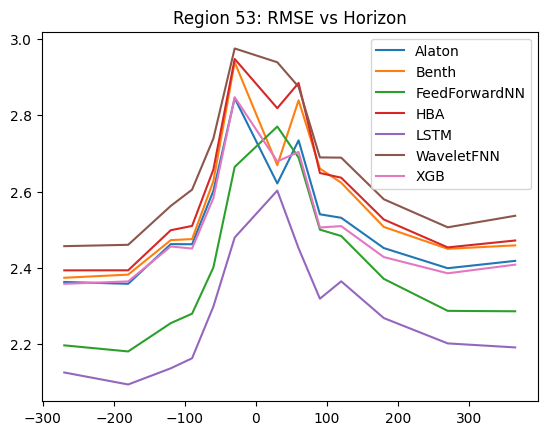

In [8]:
for region in df_long["region"].unique():
    sub = df_long[df_long["region"] == region]
    avg = sub.groupby(["model", "horizon"])["rmse"].mean().reset_index()

    plt.figure()
    for model in avg["model"].unique():
        m = avg[avg["model"] == model]
        plt.plot(m["horizon"], m["rmse"], label=model)

    plt.title(f"Region {region}: RMSE vs Horizon")
    plt.legend()
    plt.show()

# ape CAT 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bk_ape_cat.csv")

# reshape from wide to long
df_long = df.melt(
    id_vars=["region", "year", "model"],
    var_name="horizon",
    value_name="ape"
)

# keep the original horizon label
df_long["horizon_label"] = df_long["horizon"]

# numeric version where possible
df_long["horizon_num"] = pd.to_numeric(df_long["horizon"], errors="coerce")

print(df_long.head())
print(df_long["horizon_label"].unique())

   region  year       model horizon       ape horizon_label  horizon_num
0      11  2015         HBA      30  0.080777            30         30.0
1      11  2015      Alaton      30  0.045044            30         30.0
2      11  2015       Benth      30  0.188166            30         30.0
3      11  2015         XGB      30  0.084126            30         30.0
4      11  2015  WaveletFNN      30  0.262519            30         30.0
['30' '60' '90' '120' '180' '270' '365' 'ISL' 'IISL' 'mid90' '-270' '-180'
 '-120' '-90' '-60' '-30']


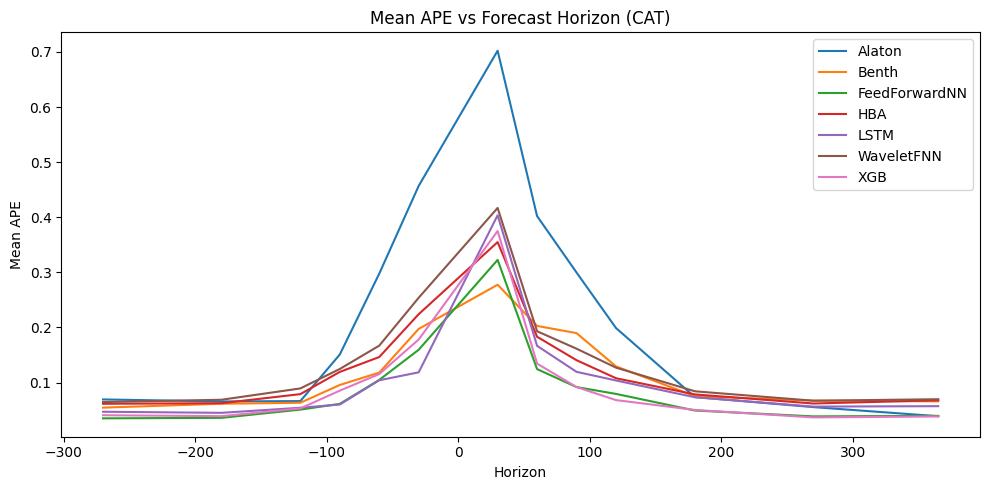

In [11]:
num_only = df_long[df_long["horizon_num"].notna()].copy()

avg = (
    num_only.groupby(["model", "horizon_num"], as_index=False)["ape"]
    .mean()
)

plt.figure(figsize=(10, 5))
for model in avg["model"].unique():
    sub = avg[avg["model"] == model].sort_values("horizon_num")
    plt.plot(sub["horizon_num"], sub["ape"], label=model)

plt.title("Mean APE vs Forecast Horizon (CAT)")
plt.xlabel("Horizon")
plt.ylabel("Mean APE")
plt.legend()
plt.tight_layout()
plt.show()